In [15]:
import sys
import pandas as pd
import datatable as dt
import numpy as np
from multiprocessing import Pool
from plotnine import *
import plotnine as plt

PATH = "/home/jmurga/mkt/202004" 
sys.path.insert(0, PATH + '/scripts/src/')  
from pyAmkt import *
from slimParser import *

Create the output directory. You should change the directory tree if you clone the github repo

In [ ]:
!mkdir -p /home/jmurga/mkt/202004/rawData/simulations /home/jmurga/mkt/202004/rawData/summStat

# No demography simulations

### Solving values to simulate with Analytical.jl

## N = 1000

In [ ]:
!which julia

Add the proper packages to your Julia session

In [ ]:
!julia -e 'using Pkg;Pkg.add("CSV");Pkg.add("DataFrames");Pkg.add(PackageSpec(path="https://github.com/jmurga/Analytical.jl"))'

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 500 200000 bgsTable

In [2]:
simTable = pd.read_csv(PATH + "/rawData/simulations/bgsTable.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)

I test two cases in the notebook case I select one row from simTable

### Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [3]:
nSamples=500
binnedSfs=(nSamples*2)-1

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim,pSize=500,codingLength=2000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,50000],threads=8,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim.tail(1),pSize=1000,codingLength=10000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,10000],threads=5,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

### Processing simulated data

#### All simulations

In [56]:
simTable=simTable.tail(3).head(1);simTable

,bgsThetaF,pposL,pposH,alphaW,alpha,estimation,B,path
9,8.220000e-10,0.003896,0.000397,0.1,0.4,0.40147,0.999,/home/jmurga/mkt/202004/rawData/simulations/no...


In [60]:
for index,row in simTable.iterrows():
    print(row.path)
    parsePolDiv(row.path,binnedSfs)

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999


100%|██████████| 50000/50000 [01:27<00:00, 572.92it/s]


In [3]:
df,dfAlpha = saveSimulatedAlphas(simTable);dfAlpha
dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.999


,f,alphas,B,alphaW,sfs,path
0,1,-0.647849,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2
1,2,-0.407424,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2
2,3,-0.332796,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2
3,4,-0.281825,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2
4,5,-0.245331,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2
...,...,...,...,...,...,...
994,995,0.066204,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999
995,996,0.084752,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999
996,997,0.106332,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999
997,998,0.035028,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999


In [4]:
df = df.round(3)

In [5]:
df.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedAlphas.tsv',index=False,sep='\t',header=True)

In [6]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotAll.tsv',index=False,sep='\t',header=True)

In [40]:
dfAlpha['path'] = pd.Categorical(dfAlpha['path'], ["noDemog_0.4_0.1_0.2","noDemog_0.4_0.2_0.2","noDemog_0.4_0.3_0.2","noDemog_0.4_0.1_0.4","noDemog_0.4_0.2_0.4","noDemog_0.4_0.3_0.4","noDemog_0.4_0.1_0.8","noDemog_0.4_0.2_0.8","noDemog_0.4_0.3_0.8","noDemog_0.4_0.1_0.999","noDemog_0.4_0.2_0.999","noDemog_0.4_0.3_0.999"])

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


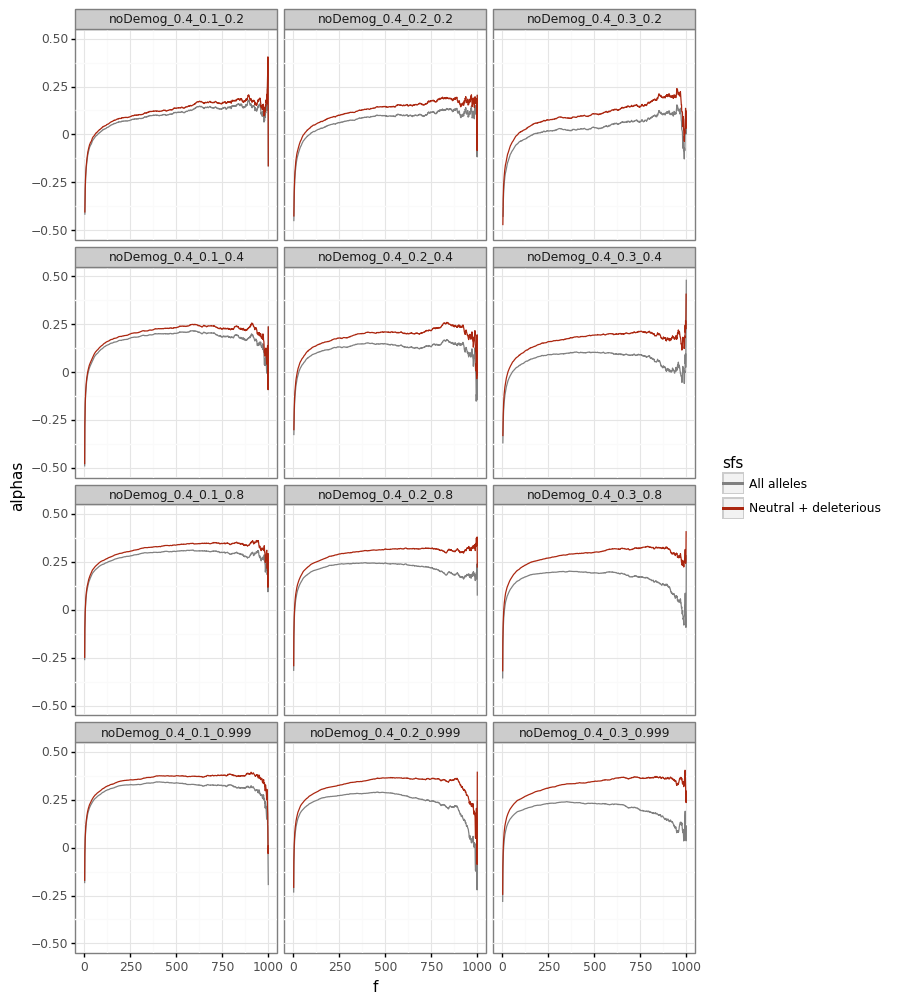

<ggplot: (8733419603246)>

In [41]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,0.5)) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw();p

In [43]:
ggsave(p,"/home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphas.jpg",dpi=600)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 8 x 12 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphas.jpg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


In [18]:
df,dfAlpha = saveSimulatedAlphas(simTable,bins=100);dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.999


,f,alphas,sfs,path
0,1,-0.647849,Neutral + deleterious,noDemog_0.4_0.1_0.2
1,2,-0.158575,Neutral + deleterious,noDemog_0.4_0.1_0.2
2,3,-0.084182,Neutral + deleterious,noDemog_0.4_0.1_0.2
3,4,-0.047678,Neutral + deleterious,noDemog_0.4_0.1_0.2
4,5,-0.028115,Neutral + deleterious,noDemog_0.4_0.1_0.2
...,...,...,...,...
95,96,0.079887,All alleles,noDemog_0.4_0.3_0.999
96,97,0.099639,All alleles,noDemog_0.4_0.3_0.999
97,98,0.132635,All alleles,noDemog_0.4_0.3_0.999
98,99,0.078286,All alleles,noDemog_0.4_0.3_0.999


In [32]:
dfAlpha['path'] = pd.Categorical(dfAlpha['path'], ["noDemog_0.4_0.1_0.2","noDemog_0.4_0.2_0.2","noDemog_0.4_0.3_0.2","noDemog_0.4_0.1_0.4","noDemog_0.4_0.2_0.4","noDemog_0.4_0.3_0.4","noDemog_0.4_0.1_0.8","noDemog_0.4_0.2_0.8","noDemog_0.4_0.3_0.8","noDemog_0.4_0.1_0.999","noDemog_0.4_0.2_0.999","noDemog_0.4_0.3_0.999"])

In [33]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotReduced.tsv',index=False,sep='\t',header=True)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


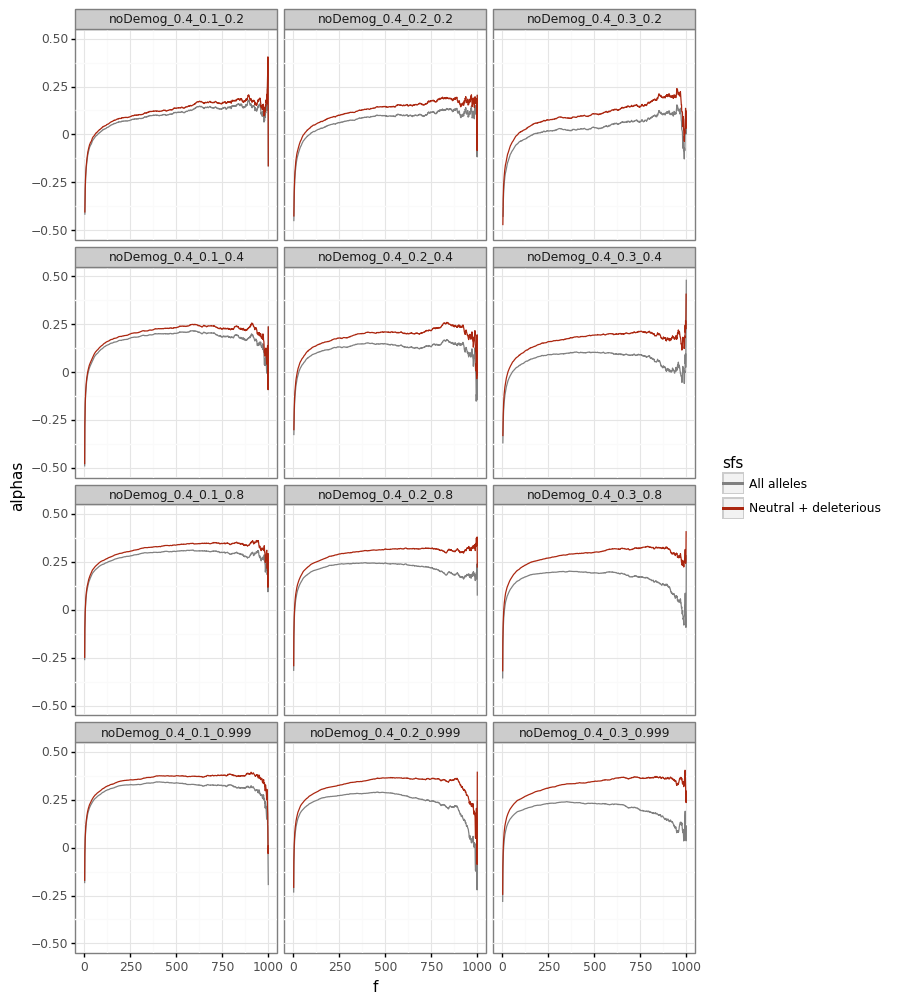

<ggplot: (8733420071084)>

In [34]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,0.5)) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw();p

In [35]:
ggsave(p,"/home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphasReduced.jpg",dpi=300)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 8 x 12 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphasReduced.jpg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


#### Sampling 10^7pb

In [ ]:
for index,row in simTable.iterrows():
    print(row.path)
    parsePolDiv(row.path,binnedSfs,10000)

In [3]:
df,dfAlpha = saveSimulatedAlphas(simTable,bins=20,sample=10000);dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,dfAlpha.alphas.max()));p

# Tennesen model

## Solving values to simulate with Analytical.jl

In [ ]:
!which julia

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 7310 100000 tennensen.tsv

### Solving values to simulate with Analytical.jl

In [2]:
simTable = pd.read_csv(PATH + "/rawData/simulations/tennesen.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/tennesen/tennesen_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)

To test just one case I select one row from simTable

In [7]:
tmpSim = simTable.tail(6)

### Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [6]:
nSamples=661
binnedSfs = (nSamples * 2) - 1

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/tennesen.slim",simTable=tmpSim,pSize=500,codingLength=2000,strongStrength=500,weaklyStrength=10,sSize=nSamples,replicas=[1,50000],threads=7,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

### Processing simulated data

In [9]:
for index,row in tmpSim.iterrows():
    parsePolDiv(row.path,1321)

100%|██████████| 50000/50000 [01:34<00:00, 530.57it/s]


In [10]:
df,dfAlpha = saveSimulatedAlphas(table=tmpSim);dfAlpha['B'] = round(dfAlpha['B'],3)

/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/tennesen/rescaled/tennesen_0.4_0.3_0.999


In [119]:
df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path
0,0.341219,0.315843,NaN,0.37008,tennesen_0.4_0.3_0.8
0,0.375848,0.342376,NaN,0.40362,tennesen_0.4_0.3_0.999
0,0.341459,0.323675,NaN,0.37008,isolation_0.4_0.3_0.8
0,0.374172,0.371417,NaN,0.40362,isolation_0.4_0.3_0.999


In [12]:
dfAlpha['group'] = dfAlpha.path + ": " + dfAlpha.sfs

In [159]:
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + ylim(-0.5,0.5) + theme_bw() + theme(legend_position='bottom')+ facet_wrap('~path',ncol=2,scales='free_x') +scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) );p
ggsave(p,filename="/home/jmurga/isolationFacet.svg")

/home/jmurga/.local/lib/python3.8/site-packages/plotnine/facets/facet.py:555: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'


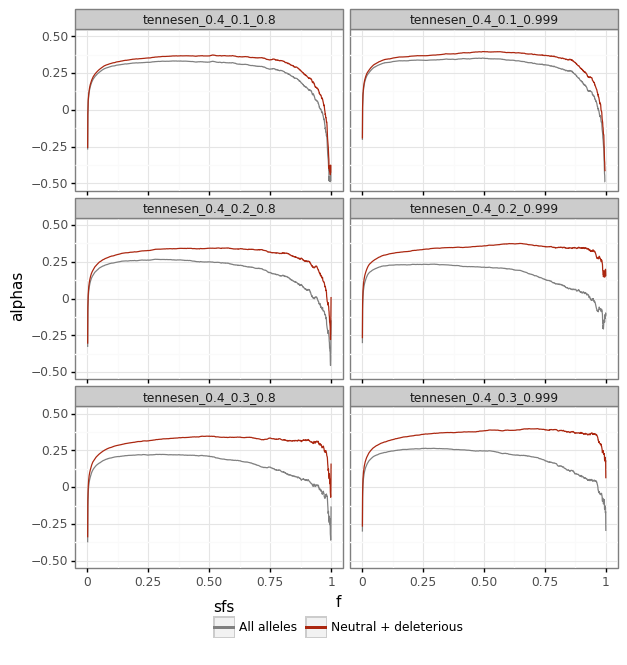

<ggplot: (8742155964305)>

In [14]:
plt.options.figure_size=(7,7)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=2,scales='free_x') + ylim(-0.5,0.5) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw() + theme(legend_position='bottom'));p
# ggsave(p,filename="/home/jmurga/tennesen_alphaweak.svg")
